# Importing Libraries 

In [10]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np 


# EXPLANATORY DATA ANALYSIS 

### 1. Introduction

- The objective of this analysis is to explore the Iris dataset to identify patterns, relationships, and key features that distinguish different species. The analysis focuses on understanding data distribution, correlations, and feature importance to support data-driven insights.

### 2. Tools & Dataset
- Tools: Python (Pandas, Matplotlib, Seaborn)
- Dataset: Iris Dataset

### 3. Loading and Prearing Dataset

In [4]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Convert labels
df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 4. Data Overview

In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


##### Insight:
- Dataset contains 150 rows and 5 columns
- Features are numerical and suitable for analysis

### 5. Summary Statistics 

In [8]:
df.groupby('species').mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


##### Insight:
- Setosa has smaller petal measurements
- Virginica has the largest measurements

### 6. Data Distribution

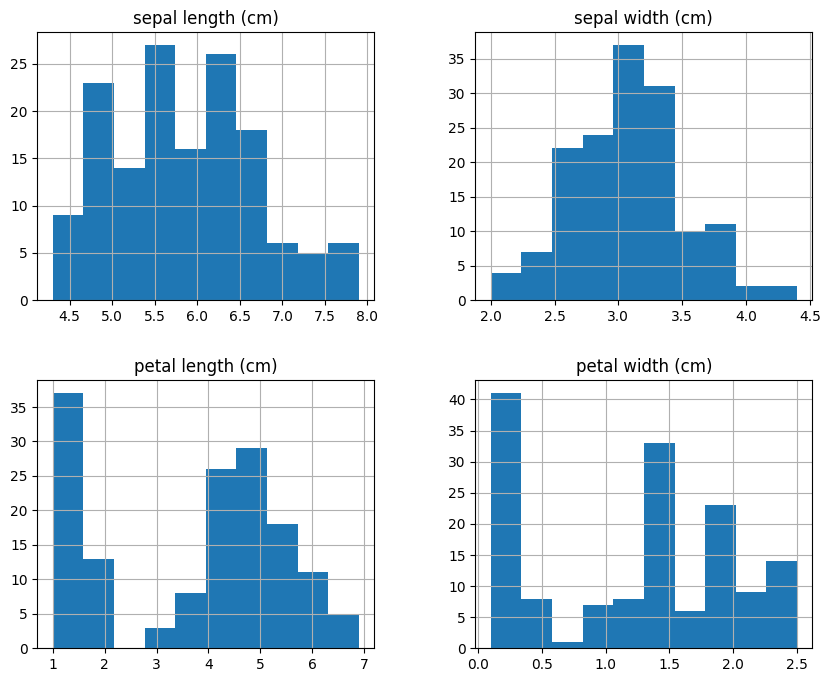

In [11]:
df.hist(figsize=(10,8))
plt.show()

##### Insight:
- Most features are normally distributed
- Petal measurements show stronger variation

### 7. Correlation Analysis 

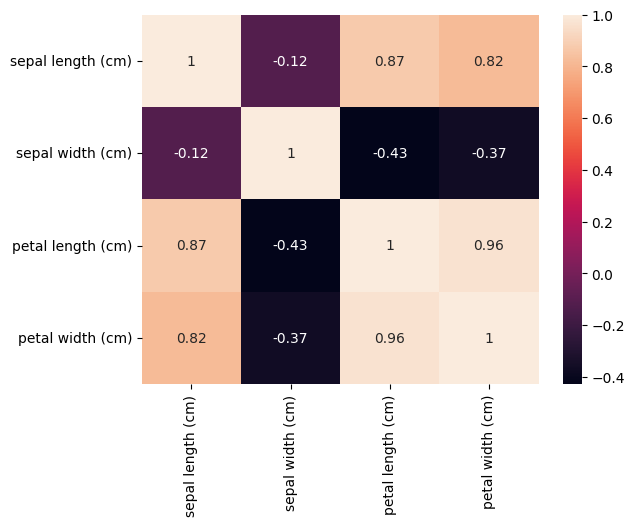

In [14]:
corr = df.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True)
plt.show()

##### Insight:
- Strong correlation between petal length and petal width
- Sepal features show weaker relationships

### 8. Species Comparison (Boxplots)

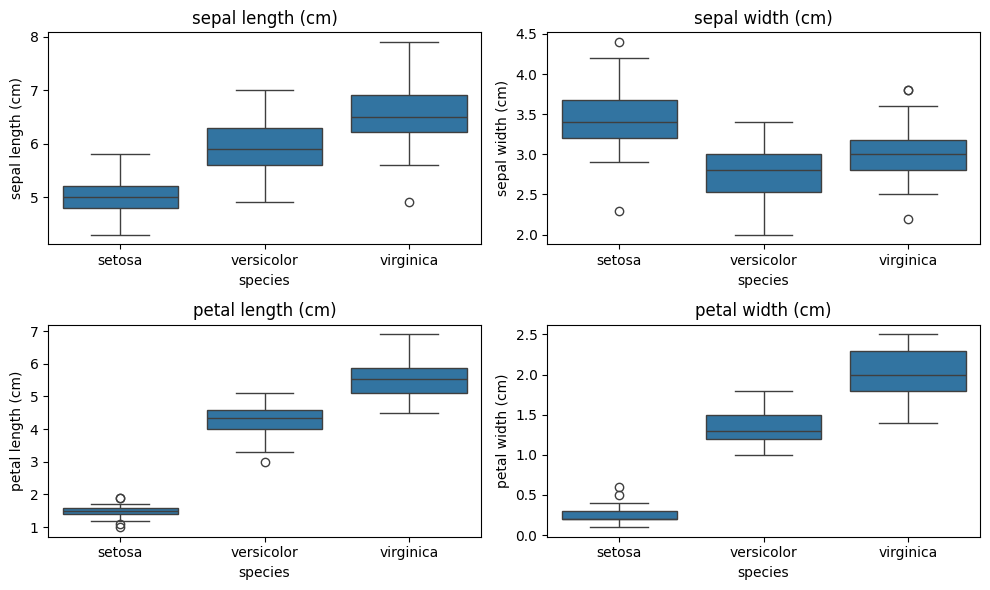

In [19]:
# Boxplots
plt.figure(figsize=(10,6))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(2,2,i+1)
    sns.boxplot(x='species', y=col, data=df)
    plt.title(col)
plt.tight_layout()
plt.show()

##### Insight:
- Clear separation between species using petal measurements
- Minimal overlap → strong classification feature

A. In the plot, you’ll notice:

- Setosa -> very small petal lengths
- Versicolor -> medium
- Virginica -> large

B. The boxplot shows a clear separation in petal length across species, with minimal overlap between groups. This indicates that petal length is a strong distinguishing feature and can be effectively used for classification.

C. Basically, I was checking which features really differentiate the species. The petal measurements stood out immediately—they separate the groups really well. The sepal ones were more mixed, so not as helpful.

### 9. Pairwise Relationships

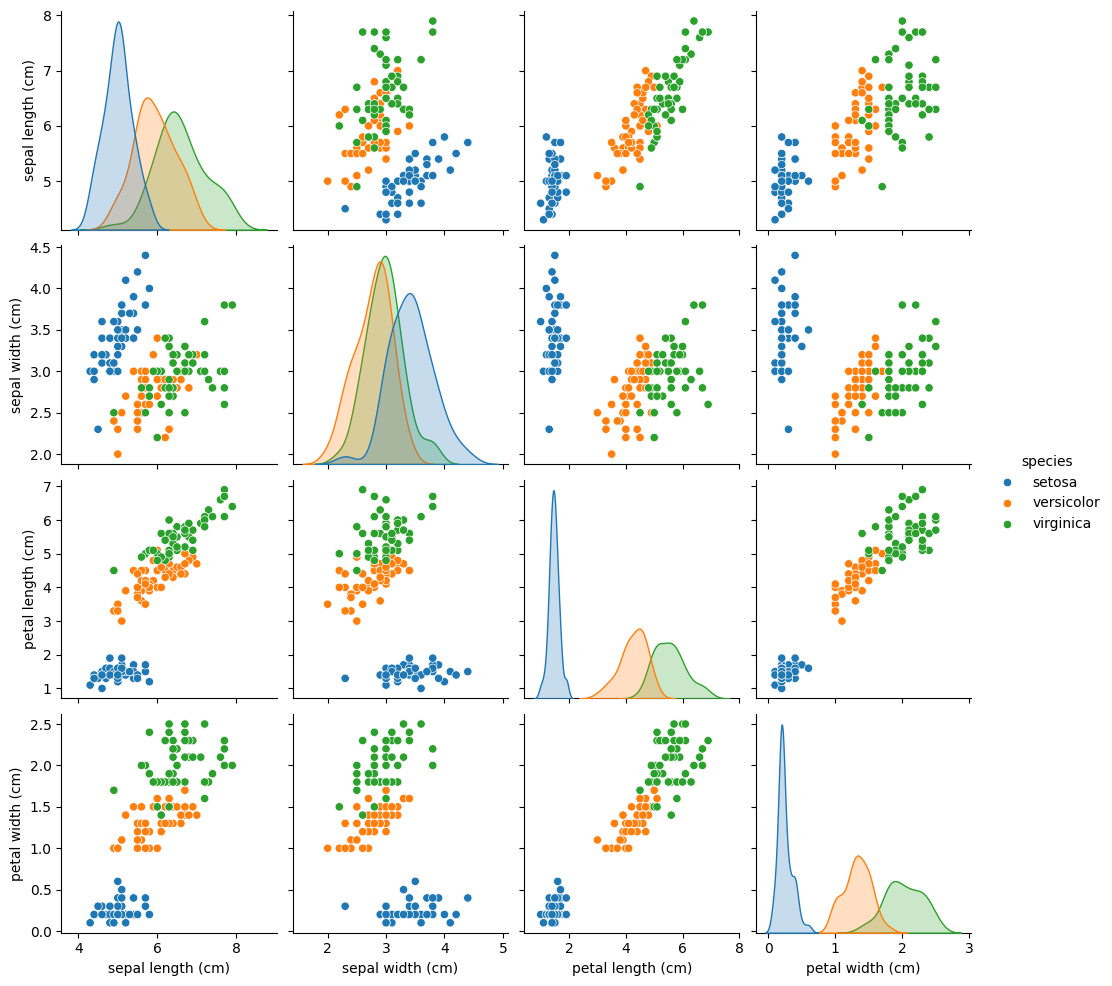

In [17]:
sns.pairplot(df, hue='species')
plt.show()

##### Insight
- The pairplot reveals that species form distinct clusters, particularly when comparing petal length and petal width. These features provide clear separation between species, while sepal features show more overlap, indicating they are less effective for classification.

### 10. Outlier Detection 

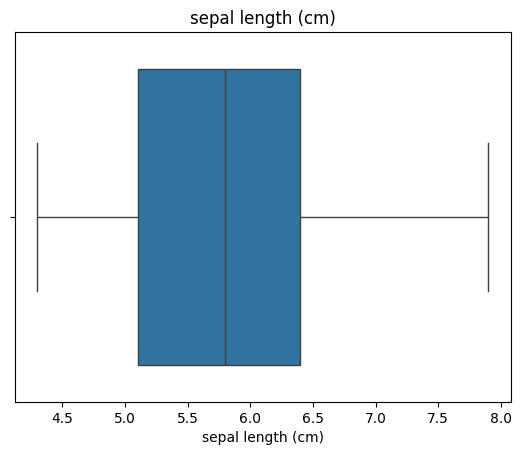

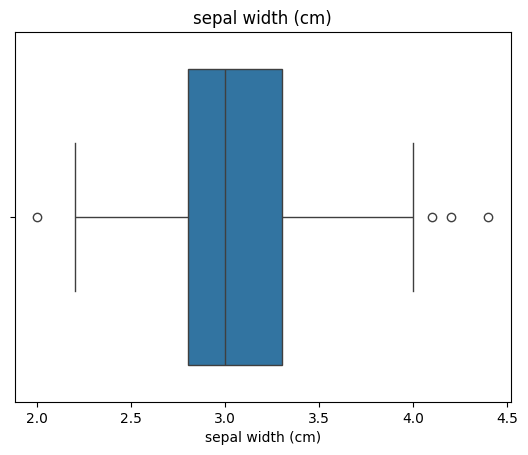

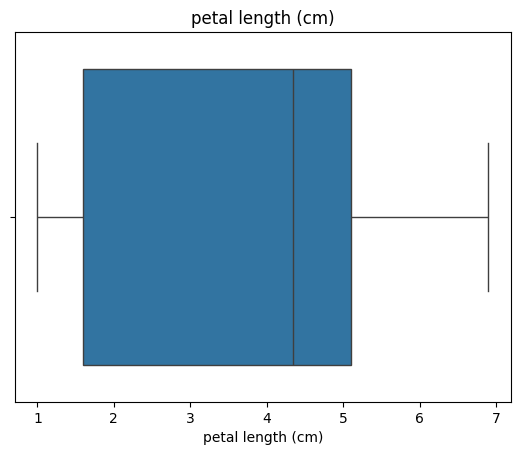

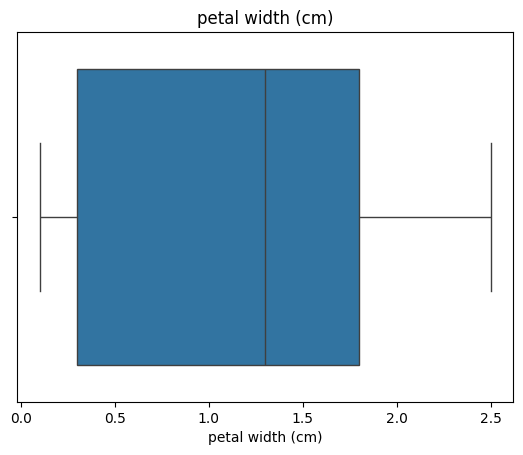

In [20]:
for col in df.columns[:-1]:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

##### Insight:
- No significant outliers detected

### 11. Feature Variance

In [22]:
df.var(numeric_only=True)

sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64

##### Insight:
- Petal features show higher variance
- Indicates stronger ability to differentiate species

## Key Findings for EDA

- Petal length and petal width are the most significant features for distinguishing between species, showing clear variation and minimal overlap across groups.  
- Setosa is completely separable from the other species due to its consistently smaller petal measurements.  
- Versicolor and Virginica show slight overlap but can still be differentiated using petal features.  
- A strong positive correlation exists between petal length and petal width, indicating potential redundancy.  
- Sepal features show weaker separation and higher overlap, making them less reliable for classification.  
- The dataset is clean, with no significant outliers or missing values.  
- The dataset is balanced across species, reducing bias in analysis.  
- The data is suitable for classification tasks and predictive modeling.  